<a href="https://colab.research.google.com/github/kimjaehwankimjaehwan/thermodynamics/blob/main/Van_der_Waals_%EC%88%98%EC%A6%9D%EA%B8%B0%EC%9D%98_%EC%83%81%ED%83%9C%EB%B0%A9%EC%A0%95%EC%8B%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Analyzing water vapor behavior using Van der Waals equation...

Critical Point:
Critical Temperature: 64.62 K
Critical Pressure: 22.02 bar
Critical Volume: 0.0915 L/mol

Generating plots...


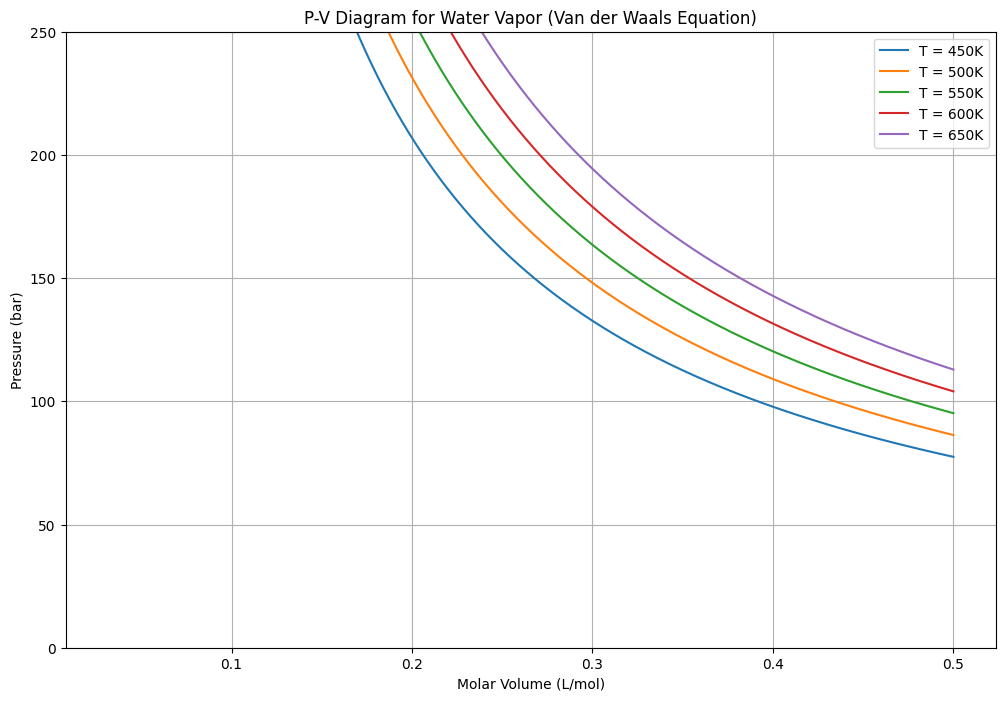

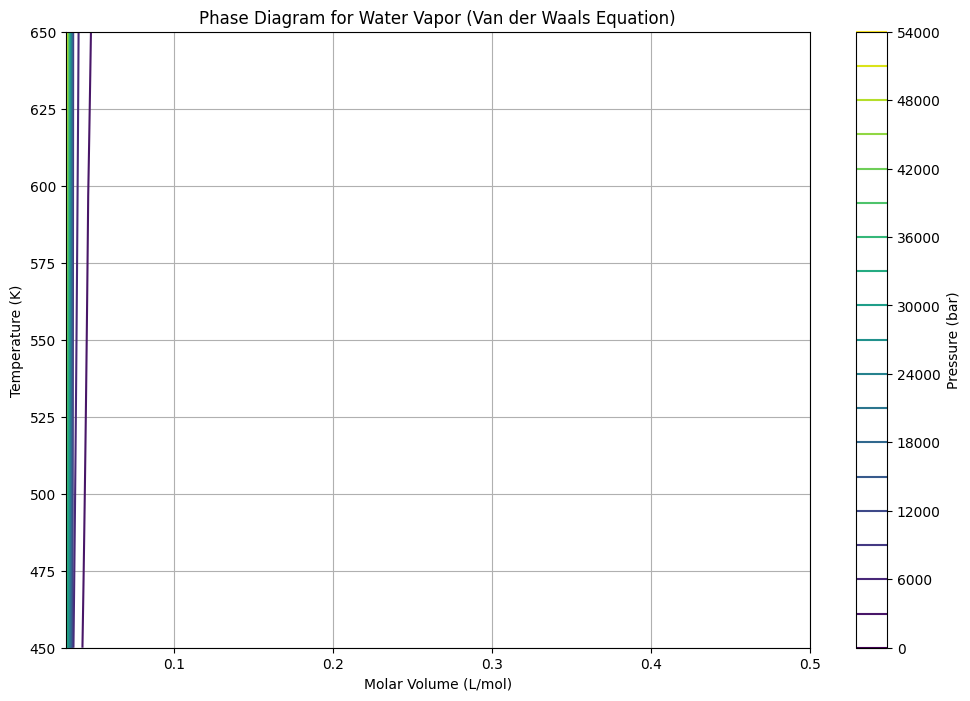

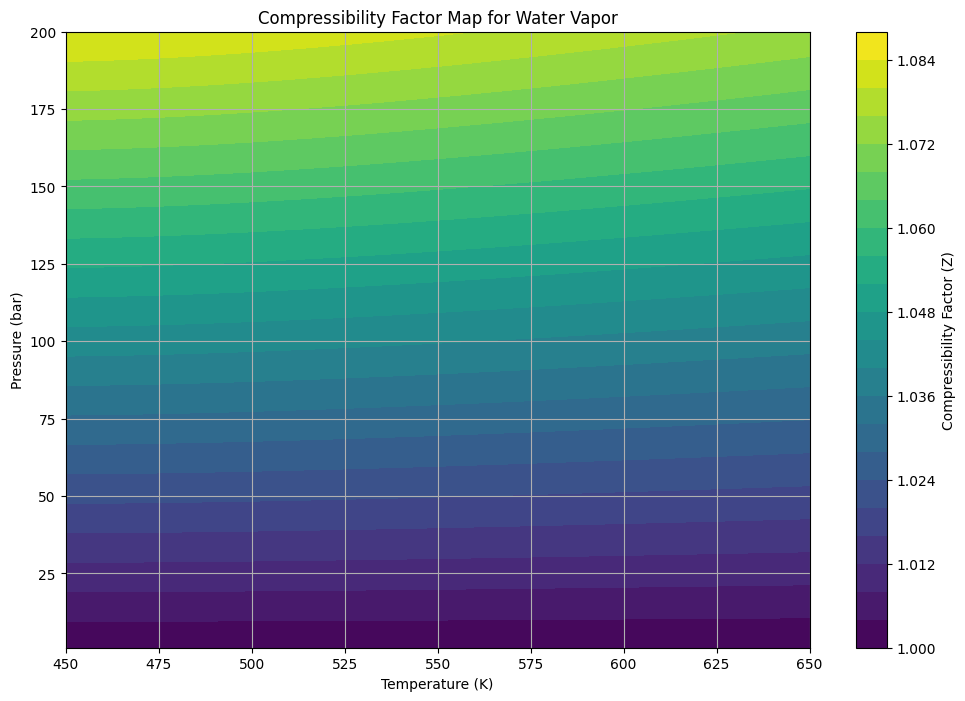


Molar volumes at T = 500K and P = 100bar:
Solution 1: 0.434363 L/mol


<ipython-input-1-3361c7fc78fe>:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  volumes.append(float(v))


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# 수증기의 Van der Waals 상수
a = 0.553  # L^2⋅bar/mol^2
b = 0.0305  # L/mol
R = 0.08314  # L⋅bar/(K⋅mol) (기체 상수)

def van_der_waals(v, T, P):
    """Van der Waals 방정식"""
    return (P + a/v**2) * (v - b) - R*T

def find_volumes(T, P):
    """주어진 온도와 압력에서 부피 계산"""
    # 초기 추측값들
    v_guesses = np.linspace(b+0.001, 1.0, 10)
    volumes = []

    for v_guess in v_guesses:
        v = fsolve(van_der_waals, v_guess, args=(T, P))
        if v > b and abs(van_der_waals(v, T, P)) < 1e-6:
            if not any(abs(vol - v) < 1e-6 for vol in volumes):
                volumes.append(float(v))

    return sorted(volumes)

def plot_pv_isotherms():
    """P-V 등온선 그래프"""
    v = np.linspace(b+0.001, 0.5, 1000)
    temperatures = [450, 500, 550, 600, 650]  # K

    plt.figure(figsize=(12, 8))

    for T in temperatures:
        P = R*T/(v - b) - a/v**2
        plt.plot(v, P, label=f'T = {T}K')

    plt.xlabel('Molar Volume (L/mol)')
    plt.ylabel('Pressure (bar)')
    plt.title('P-V Diagram for Water Vapor (Van der Waals Equation)')
    plt.ylim(0, 250)
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_phase_diagram():
    """상 다이어그램"""
    T = np.linspace(450, 650, 100)
    v = np.linspace(b+0.001, 0.5, 100)
    T_mesh, v_mesh = np.meshgrid(T, v)
    P_mesh = R*T_mesh/(v_mesh - b) - a/v_mesh**2

    plt.figure(figsize=(12, 8))
    plt.contour(v_mesh, T_mesh, P_mesh, levels=20)
    plt.colorbar(label='Pressure (bar)')
    plt.xlabel('Molar Volume (L/mol)')
    plt.ylabel('Temperature (K)')
    plt.title('Phase Diagram for Water Vapor (Van der Waals Equation)')
    plt.grid(True)
    plt.show()

def calculate_critical_point():
    """임계점 계산"""
    # 임계점에서의 온도
    Tc = 8*a/(27*R*b)
    # 임계점에서의 압력
    Pc = a/(27*b**2)
    # 임계점에서의 부피
    Vc = 3*b

    print(f"Critical Point:")
    print(f"Critical Temperature: {Tc:.2f} K")
    print(f"Critical Pressure: {Pc:.2f} bar")
    print(f"Critical Volume: {Vc:.4f} L/mol")

def analyze_compressibility():
    """압축인자 분석"""
    T = np.linspace(450, 650, 100)
    P = np.linspace(1, 200, 100)
    T_mesh, P_mesh = np.meshgrid(T, P)

    # 이상 기체 부피
    v_ideal = R*T_mesh/P_mesh

    # Van der Waals 부피 (근사값)
    v_real = v_ideal * (1 + b*P_mesh/(R*T_mesh) - a/(R*T_mesh*v_ideal))

    # 압축인자
    Z = P_mesh*v_real/(R*T_mesh)

    plt.figure(figsize=(12, 8))
    plt.contourf(T_mesh, P_mesh, Z, levels=20)
    plt.colorbar(label='Compressibility Factor (Z)')
    plt.xlabel('Temperature (K)')
    plt.ylabel('Pressure (bar)')
    plt.title('Compressibility Factor Map for Water Vapor')
    plt.grid(True)
    plt.show()

# 모든 분석 실행
print("Analyzing water vapor behavior using Van der Waals equation...\n")

calculate_critical_point()
print("\nGenerating plots...")

plot_pv_isotherms()
plot_phase_diagram()
analyze_compressibility()

# 특정 조건에서의 부피 계산 예시
T_example = 500  # K
P_example = 100  # bar
volumes = find_volumes(T_example, P_example)
print(f"\nMolar volumes at T = {T_example}K and P = {P_example}bar:")
for i, v in enumerate(volumes):
    print(f"Solution {i+1}: {v:.6f} L/mol")

1. P-V 등온선 그래프:
  - 여러 온도에서의 압력-부피 관계를 보여줍니다.
  - 상전이 영역을 포함한 전체적인 거동을 시각화합니다.


2. 상 다이어그램:
  - 온도-부피-압력의 3차원 관계를 등고선으로 표현합니다.
  - 상전이 경계를 시각화합니다.


3. 임계점 계산:
  - 수증기의 임계온도, 임계압력, 임계부피를 계산합니다.
  - Van der Waals 상수를 사용한 정확한 계산을 제공합니다.


4. 압축인자 분석:
  - 다양한 온도와 압력에서의 압축인자(Z)를 계산합니다.
  - 이상기체로부터의 편차를 시각화합니다.


5. 특정 조건에서의 부피 계산:
  - 주어진 온도와 압력에서 가능한 모든 부피값을 계산합니다.
  - 상전이 영역에서 multiple solutions를 찾아냅니다.